# Water-gas shift
$$
\newcommand{\dd}{\mathrm{d}}
\newcommand{\Pressure}{p}
\newcommand{\PartialPressure}[1]{p_{#1}}
\newcommand{\MolarFlowRate}[1]{F_{#1}}
%
\newcommand{\ReactionRate}[1]{r_{#1}}
\newcommand{\RateFormation}[1]{R_{#1}}
\newcommand{\RateCoef}[1]{k_{#1}}
\newcommand{\EquilibriumConst}[1]{K_{#1}}
$$

In [1]:
from datetime import datetime
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Latex

from phdtools import DATA_DIR
from phdtools.data.constants import GAS_CONST_SI
from phdtools.rdm import (
    DataID,
    DataType,
    Chapter,
    auto_create_path,
    write_metadata,
    request_free_id,
)

overwrite = False
FILE_DATE = os.getenv("FILE_DATE", "260321")
TODAY = datetime.today().strftime("%y%m%d")

if overwrite:
    FILE_DATE = TODAY

$$
\ce{CO + H2O <=> CO2 + H2} \label{eq:WGS}\tag{II}
$$

## Table of contents

- [Temperature dependence of the equilibrium constant](#Temperature-dependence-of-the-equilibrium-constant)
- [Stoichiometry](#Stoichiometry)
- [Equilibrium conversion](#Equilibrium-conversion)
- [Mendes et al., 2010](#Mendes-et-al.,-2010)
    - [Space-time vs. conversion](#Space-time-vs.-conversion) 
- [Choi and Stenger, 2003](#Choi-and-Stenger,-2003)

## Temperature dependence of the equilibrium constant
[back](#Table-of-contents)

The equilibrium constant is defined as
$$
K_i = \exp{\left(-\Delta_\mathrm{r} G_i^\circ/RT\right)} = \prod_{i}{a_i}^{\nu_i} \approx \prod_{i}{\left(\frac{p_i}{p^\circ}\right)}^{\nu_i}
$$

For the water-gas shift reaction \eqref{eq:WGS}
$$
K_2 = \frac{p_\ce{CO2}p_\ce{H2}}{p_\ce{CO}p_\ce{H2O}}
$$

In [2]:
from phdtools.models.choi_stenger_2003 import (
    equilibriumConstModel,
    logEquilibriumConst,
    refTemperatureEquilibriumSI,
    equilibriumConstRef,
)

In [3]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 11)

temperatureRange = np.linspace(298.15, 1000)
logEqulibriumConstModelValues = np.empty((3, len(temperatureRange)))
logEqulibriumConstModelValues[:] = np.nan

mask = (logEquilibriumConst.index >= temperatureRange.min()) & (
    logEquilibriumConst.index <= temperatureRange.max()
)
logEquilibriumConstTabulated = logEquilibriumConst[mask]

for num, model in enumerate(["choi11", "choi12", "vantHoff"]):
    logEqulibriumConstModelValues[num] = np.log(
        equilibriumConstModel(temperatureRange, model)
    ).T


@auto_create_path
def save_wgs_equilibrium_cost_model(path):
    fname = path / f"{TODAY}_log_equilibrium_const_model.csv"
    with open(fname, "w+") as f:

        # Model values
        description = (
            f"Values for the equilibrium constant of the water gas shift reaction (log K) at "
            f"different temperatures for three model variants:\n"
            f"- 'choi11': refers to eq. (11) in Choi and Stenger (2003), which is a model "
            f"proposed by Chinchen et al. (1988).\n"
            f"- 'choi12': refers to eq. (12) in Choi and Stenger (2003), which is a model "
            f"proposed by Moe (1961).\n"
            f"- 'vantHoff': refers to a van't Hoff model with T_ref = {refTemperatureEquilibriumSI} K "
            f"and K = {equilibriumConstRef:.2f} based on Allison (2013).\n"
            f"\n"
            "References:\n"
            "-----------\n"
            'Allison, T. (2013) "NIST-JANAF Thermochemical Tables - SRD 13." National Institute.\n'
            "    of Standards and Technology. Available at: https://doi.org/10.18434/T42S31.\n\n"
            "Choi, Y. and Stenger, H.G. (2003) ‘Water gas shift reaction kinetics and reactor modeling for fuel cell grade hydrogen’,\n"
            "    Journal of Power Sources, 124(2), pp. 432–439. Available at: https://doi.org/10.1016/S0378-7753(03)00614-1.\n\n"
            "Chinchen, G.C. et al. (1988) ‘Synthesis of Methanol’, Applied Catalysis, 36, pp. 1–65.\n"
            "    Available at: https://doi.org/10.1016/S0166-9834(00)80103-7.\n\n"
            "Moe, J M (1961). Design of water-gas shift reactors. Chem. Eng. Prog.; (United States), 58:3.\n\n"
        )
        write_metadata(f, description)
        np.savetxt(
            f,
            np.c_[temperatureRange, logEqulibriumConstModelValues.T],
            header="T(K),choi11,choi12,vantHoff",
            delimiter=",",
            comments="",
            fmt=["%d", "%.18e", "%.18e", "%.18e"],
        )

    # Tabulated values
    fname = path / f"{TODAY}_log_equilibrium_const_nist.csv"
    with open(fname, "w+") as f:
        description = (
            f"Values for the equilibrium constant of the water gas shift reaction (log K) at "
            f"different temperatures taken from Allison, T. (2013)\n"
            f"----\n"
            f"Allison, T. (2013) ‘NIST-JANAF Thermochemical Tables - SRD 13’. National Institute of Standards and Technology."
            f"Available at: https://doi.org/10.18434/T42S31."
        )
        write_metadata(f, description)
        logEquilibriumConstTabulated["WGS"].to_csv(f)


save_wgs_equilibrium_cost_model(
    data_id,
    doc=(
        r"Equilibrium constant of the water gas shift reaction at different temperatures for different models with reference values "
        r"taken from \textcite{Allison.2013a}; see \textcite{Choi.2003a} and references therein"
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/LKpOHA' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [4]:
!ls {data_id.get_path(fail_exists=False)}

260321_log_equilibrium_const_model.csv 260321_log_equilibrium_const_nist.csv


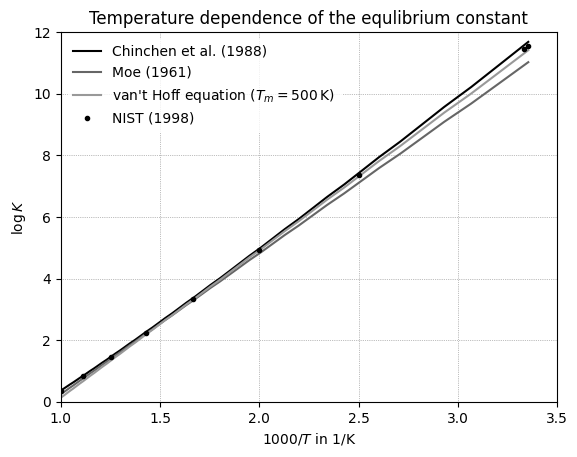

In [5]:
from phdtools.plots.wgs import plot_eq_constant_temperature_dependence

fig = plot_eq_constant_temperature_dependence(
    file_model=DataID(DataType.FIGURE, Chapter.UNUSED, 11).get_path(fail_exists=False)
    / f"{FILE_DATE}_log_equilibrium_const_model.csv",
    file_tabulated=DataID(DataType.FIGURE, Chapter.UNUSED, 11).get_path(
        fail_exists=False
    )
    / f"{FILE_DATE}_log_equilibrium_const_nist.csv",
)

## Stoichiometry
[back](#Table-of-contents)

$$
F_{\ce{CO},0} - F_{\ce{CO}} 
= F_{\ce{H2O},0} - F_{\ce{H2O}} 
= F_{\ce{CO2}} - F_{\ce{CO2},0} 
= F_{\ce{H2}} - F_{\ce{H2},0}
$$
or 
$$
x_{\ce{CO},0} - x_{\ce{CO}} 
= x_{\ce{H2O},0} - x_{\ce{H2O}} 
= x_{\ce{CO2}} - x_{\ce{CO2},0} 
= x_{\ce{H2}} - x_{\ce{H2},0}
$$

Define
$$
X_\ce{CO} = \frac{F_{\ce{CO},0} - F_{\ce{CO}}}{F_{\ce{CO},0}} 
$$

Thus 

$$
\begin{aligned}
    \frac{p_{\ce{CO}}}{p_{\ce{CO},0}} &= 1 - X_\ce{CO} \\
    \frac{p_{\ce{H2O}}}{p_{\ce{CO},0}} &= \frac{p_{\ce{H2O},0}}{p_{\ce{CO},0}} - X_\ce{CO} \\
    \frac{p_{\ce{CO2}}}{p_{\ce{CO},0}} &= \frac{p_{\ce{CO2},0}}{p_{\ce{CO},0}} + X_\ce{CO}  \\
    \frac{p_{\ce{H2}}}{p_{\ce{CO},0}} &= \frac{p_{\ce{H2},0}}{p_{\ce{CO},0}} + X_\ce{CO}  \\
\end{aligned}
$$

In [6]:
from phdtools.models.choi_stenger_2003 import stoichiometryShift, Compound

# see Kazdal (2019, fig. 2.24)
moleFractionIn = np.zeros(len(Compound))
moleFractionIn[Compound["H2(ref)"].value] = 0.56
moleFractionIn[Compound["H2O1(g)"].value] = 0.27
moleFractionIn[Compound["C1O1(g)"].value] = 0.10
moleFractionIn[Compound["C1O2(g)"].value] = 0.07

moleFractionOut = stoichiometryShift(moleFractionIn, conversion=1)
moleFractionOut[Compound["H2O1(g)"].value]

Latex(
    rf"$x^\mathrm{{out}}_\mathrm{{H_2O(g)}} = {moleFractionOut[Compound["H2O1(g)"].value]:.4f}$"
)

<IPython.core.display.Latex object>

## Equilibrium conversion
[back](#Table-of-contents)

$$
\begin{aligned}
    K &= \prod_{i} a_i^{\nu_i} \\
    \ln K &= \ln\left( \prod_{i} a_i^{\nu_i} \right)\\
    \ln K &= \sum_{i} \nu_i \ln a_i
\end{aligned}
$$

For \eqref{eq:WGS} assuming ideal gas behavior ($a_i = p_i / p^\circ$)
$$
\begin{aligned}
    \ln K_2 &= \ln\left( \prod_{i} x_i^{\nu_i} \right)\\
    \ln K_2 &= \ln x_\ce{CO2} + \ln x_\ce{H2} - \ln x_\ce{CO} - \ln x_\ce{H2O}
\end{aligned}
$$


$$
x_{\ce{CO},0} - x_{\ce{CO}} 
= x_{\ce{H2O},0} - x_{\ce{H2O}} 
= x_{\ce{CO2}} - x_{\ce{CO2},0} 
= x_{\ce{H2}} - x_{\ce{H2},0}
$$

In [7]:
from phdtools.models.choi_stenger_2003 import equilibriumConversionWGS, equilibriumConstModel

In [8]:
# see Kazdal (2019, fig. 2.24)
pressureBar = 1
temperatureRange = np.arange(200, 460, 10) + 273.15

eqConversion = np.zeros(len(temperatureRange))
moleFractionOut = np.zeros((len(temperatureRange), len(Compound)))

eqConversion[:] = np.nan
moleFractionOut[:] = np.nan

for num, temperatureKelvin in enumerate(temperatureRange):
    eqConversion[num] = equilibriumConversionWGS(
        moleFractionIn, temperatureKelvin, model="vantHoff"
    )
    moleFractionOut[num] = stoichiometryShift(moleFractionIn, eqConversion[num])

In [9]:
import scipy
from phdtools.models.choi_stenger_2003 import (
    refTemperatureEquilibriumSI,
    enthalpyReactionSI,
)

# request_free_id(DataType.FIGURE, Chapter.UNUSED)

In [10]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 12)

description = (
    f"Water-gas shift equilibrium mole fractions.\n"
    f"Solved using scipy.optimize.minimize_scalar (scipy {scipy.__version__}); \n"
    f"Equilibrium constant modelled with van't Hoff model (Tr = {refTemperatureEquilibriumSI} K,"
    f" dHr = {enthalpyReactionSI/1000}kJ/mol) based on Allison (2013).\n"
    f"Parameters: \n"
    f"  p = {pressureBar} bar;\n"
    + "; \n".join(
        f"  x_{idx.name},0 = {moleFractionIn[idx.value]:.2f}" for idx in Compound
    )
    + (
        "\n\n"
        "References:\n"
        "-----------\n"
        'Allison, T. (2013) "NIST-JANAF Thermochemical Tables - SRD 13." National Institute.\n'
        "    of Standards and Technology. Available at: https://doi.org/10.18434/T42S31.\n\n"
        'Virtanen, P. et al. (2020) "SciPy 1.0: fundamental algorithms for scientific \n'
        '    computing in Python," Nature Methods, 17(3), pp. 261–272. \n'
        "    Available at: https://doi.org/10.1038/s41592-019-0686-2.\n"
    )
)


@auto_create_path
def save_equilibrium_shift_reactor(path):
    fname = path / f"{TODAY}_eq_mole_fractions_shift.csv"
    with open(fname, "w+") as f:
        write_metadata(f, description=description)
        np.savetxt(
            f,
            np.c_[temperatureRange, moleFractionOut],
            header="T(K),"
            + ",".join(f"{Compound(i).name}" for i in range(moleFractionOut.shape[1])),
            comments="",
            delimiter=",",
            fmt=",".join(["%.2f", *(moleFractionOut.shape[1] * ["%.18e"])]),
        )


save_equilibrium_shift_reactor(
    data_id,
    doc=r"Equilibrium mole fractions for the water-gas shift reaction calculated based on a van 't Hoff model using data from \textcite{Allison.2013a}",
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/GpUncl' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [11]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 12).get_path(fail_exists=False)}

260321_eq_mole_fractions_shift.csv


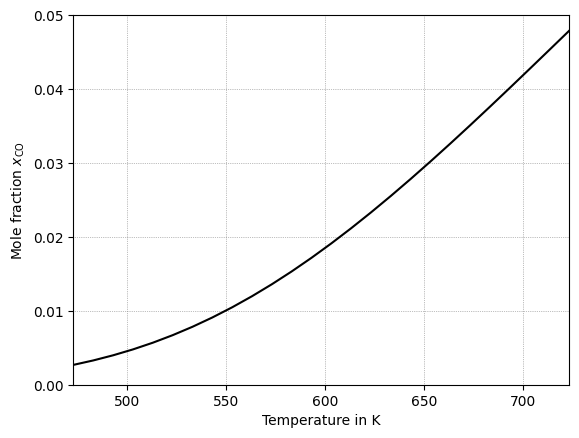

In [12]:
from phdtools.plots.wgs import plot_equilibrium_shift_reactor

fig = plot_equilibrium_shift_reactor(
    fname=DataID(DataType.FIGURE, Chapter.UNUSED, 12).get_path(fail_exists=False)
    / f"{FILE_DATE}_eq_mole_fractions_shift.csv"
)

## Mendes et al., 2010
[back](#Table-of-contents)

In [13]:
!ls {DATA_DIR / "mendes-2010"}

250725_figure_2_experimental_mendes_et_al_2010.csv
250729_table_1_mendes_et_al_2010.csv
250804_table_3_mendes_et_al_2010.csv


### Space-time vs. conversion 

In [14]:
fname = DATA_DIR / "mendes-2010" / "250725_figure_2_experimental_mendes_et_al_2010.csv"

df = pd.read_csv(fname, comment="#")
df.head()

,"W/F_CO,0(gcat*h/mol)",X_CO,T(C)
0,8.447920,0.213987,180
1,10.640443,0.253653,180
2,12.725271,0.308977,180
3,25.813031,0.431106,180
4,35.781716,0.544885,180


In [15]:
pressureBar = 1.2

moleFractionIn = np.zeros(len(Compound))

moleFractionIn[Compound["C1H4(g)"].value] = 0
moleFractionIn[Compound["C1O1(g)"].value] = 0.0470
moleFractionIn[Compound["C1O2(g)"].value] = 0.1016
moleFractionIn[Compound["H2(ref)"].value] = 0.2870
moleFractionIn[Compound["H2O1(g)"].value] = 0.3478
moleFractionIn[Compound["N2(ref)"].value] = 1 - moleFractionIn.sum()

moleFractionIn

array([0.    , 0.047 , 0.1016, 0.287 , 0.3478, 0.    , 0.2166, 0.    ])

In [16]:
from phdtools.models.mendes_2010 import ModelParameters

params = {
    model: ModelParameters.init(model=model)
    for model in ["Moe", "Power law", "LH1", "LH2", "Redox"]
}

In [17]:
fname = DATA_DIR / "mendes-2010" / "250804_table_3_mendes_et_al_2010.csv"

tmp = pd.read_csv(
    fname,
    usecols=[0, 1, 3],
    names=["Parameter", "LH1", "Redox"],
    header=None,
    skiprows=[0, 1, 12],
    index_col=0,
)
tmp

,LH1,Redox
Parameter,,
k0,1.188000e+00,0.001841
Ea,3.666000e+02,6.710000
"KCO,0",2.283000e-24,NaN
"KH2O,0",1.957000e-28,NaN
"KCO2,0",5.419000e-04,0.634300
"KH2,0",2.349000e-04,NaN
dHCO,-4.599600e+01,NaN
dHH2O,-7.996300e+01,NaN
dHCO2,-1.647400e+01,-19.459000


In [18]:
params["Combined"] = {
    "Low Temp": ModelParameters.init(model="LH1", frame=tmp),
    "High Temp": ModelParameters.init(model="Redox", frame=tmp),
}
params["Combined"]["Low Temp"].activationEnergySI *= 1e-1  # ???

In [19]:
from scipy.integrate import solve_ivp
from phdtools.models.mendes_2010 import initialValueProblemSpaceTime

In [20]:
data_id = DataID(DataType.FIGURE, Chapter.METHODS, 14)

# Solve initial value problem
temperatureRange = np.array([180, 190, 200, 230, 250, 300]) + 273.15
spaceTime = np.linspace(0, 80) * 3.6
conversion = dict()

for key, value in params.items():

    conversion[key] = np.zeros((len(temperatureRange), len(spaceTime)))
    conversion[key][:] = np.nan

    for num, temperatureKelvin in enumerate(temperatureRange):
        if key == "Combined":
            if temperatureKelvin <= 215 + 273.15:
                p = value["Low Temp"]
            elif temperatureKelvin > 215 + 273.15:
                p = value["High Temp"]
        else:
            p = value
        # eqConversion = equilibriumConversionWGS(moleFractionIn, temperatureKelvin, model="vantHoff")[0][0]
        # conversion[num] = np.linspace(0, eqConversion - 1e-6, 100)
        sol = solve_ivp(
            fun=initialValueProblemSpaceTime,
            t_span=[spaceTime.min(), spaceTime.max()],
            y0=[0],
            method="RK45",
            t_eval=spaceTime,
            dense_output=False,
            events=None,
            vectorized=True,
            args=(moleFractionIn, temperatureKelvin, pressureBar, p),
        )

        conversion[key][num] = sol.y[0]


# Save solutions to file
@auto_create_path
def save_space_time_conversion_mendes_2010(path):
    for model in conversion.keys():
        description = (
            f"Plug flow reactor simulation data ({model} model) recreating Mendes et al. (2010, fig. 2).\n"
            f"Solved using the RKF45 method implementation of scipy.integrate.solve_ivp (scipy {scipy.__version__}); \n"
            f"Equilibrium constant modelled by a van't Hoff model (Tr = {refTemperatureEquilibriumSI} K,"
            f" dHr = {enthalpyReactionSI/1000}kJ/mol) based on Allison (2013), see {DataID(DataType.FIGURE, Chapter.UNUSED, 11).to_sqid()}.\n"
            f"Parameters: \n"
            f"  p = {pressureBar} bar;\n"
            + "; \n".join(
                f"  x_{idx.name},0 = {moleFractionIn[idx.value]}" for idx in Compound
            )
            + (
                "\n\n"
                "References:\n"
                "-----------\n"
                'Allison, T. (2013) "NIST-JANAF Thermochemical Tables - SRD 13." National Institute.\n'
                "    of Standards and Technology. Available at: https://doi.org/10.18434/T42S31.\n\n"
                "Mendes, D. et al. (2010) “Determination of the Low-Temperature Water−Gas Shift Reaction \n"
                "   Kinetics Using a Cu-Based Catalyst,” Industrial & Engineering Chemistry Research, 49(22), pp. 11269–11279.\n"
                "   Available at: https://doi.org/10.1021/ie101137b.\n\n"
                'Virtanen, P. et al. (2020) "SciPy 1.0: fundamental algorithms for scientific \n'
                '   computing in Python," Nature Methods, 17(3), pp. 261–272. \n'
                "   Available at: https://doi.org/10.1038/s41592-019-0686-2.\n"
            )
        )

        header = (
            "W/FCO,0(g(cat)*h/mol)"
            + ","
            + ",".join(
                f"{temperatureKelvin-273.15:.0f}(C)"
                for temperatureKelvin in temperatureRange
            )
        )
        fname = path / f"{TODAY}_space_time_conversion_{model.replace(" ", "_")}.csv"
        with open(fname, "w+") as f:
            write_metadata(f, description=description)
            np.savetxt(
                f,
                np.c_[spaceTime / 3.6, conversion[model].T],
                header=header,
                comments="#",
                delimiter=",",
            )


save_space_time_conversion_mendes_2010(
    data_id,
    doc=r"Space time vs. conversion plot for the water-gas shift reaction (isothermal plug flow reactor) recreating \textcite[fig. 2]{Mendes.2010a}",
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/RgeyN7' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [21]:
!ls {DataID(DataType.FIGURE, Chapter.METHODS, 14).get_path(fail_exists=False)}

260321_space_time_conversion_Combined.csv
260321_space_time_conversion_LH1.csv
260321_space_time_conversion_LH2.csv
260321_space_time_conversion_Moe.csv
260321_space_time_conversion_Power_law.csv
260321_space_time_conversion_Redox.csv


In [22]:
from phdtools.plots.wgs import plot_space_time_conversion_mendes_2010


def create_plot(model):
    fig = plot_space_time_conversion_mendes_2010(
        file_experiment=DATA_DIR
        / "mendes-2010"
        / "250725_figure_2_experimental_mendes_et_al_2010.csv",
        file_model=DataID(DataType.FIGURE, Chapter.METHODS, 14).get_path(
            fail_exists=False
        )
        / f"{FILE_DATE}_space_time_conversion_{model.replace(" ", "_")}.csv",
        model=model,
    )
    plt.show()

In [23]:
import ipywidgets as widgets

dropdown = widgets.Dropdown(
    options=["Moe", "Power law", "LH1", "LH2", "Redox", "Combined"],
    value="Moe",
    description="Model:",
)
_ = widgets.interact(create_plot, model=dropdown)

interactive(children=(Dropdown(description='Model:', options=('Moe', 'Power law', 'LH1', 'LH2', 'Redox', 'Comb…

### Pairity plots for the conversion rate

In [24]:
fname = DATA_DIR / "mendes-2010" / "250725_figure_2_experimental_mendes_et_al_2010.csv"

df = pd.read_csv(fname, comment="#")
df.head()

,"W/F_CO,0(gcat*h/mol)",X_CO,T(C)
0,8.447920,0.213987,180
1,10.640443,0.253653,180
2,12.725271,0.308977,180
3,25.813031,0.431106,180
4,35.781716,0.544885,180


In [25]:
def estimate_reaction_rate(conversion, spaceTime, method="forward"):

    retval = np.zeros(len(spaceTime))
    retval[:] = np.nan

    if method == "forward":
        retval = np.diff(conversion) / np.diff(spaceTime)
        retval = np.append(retval, np.nan)
    elif method == "backward":
        retval = np.diff(conversion)[::-1] / np.diff(spaceTime)[::-1]
        retval = np.append(np.nan, retval)
    elif method == "central":
        retval = np.gradient(conversion, spaceTime)
        # retval[0] = np.nan
        # retval[-1] = np.nan
    else:
        ValueError("Unknown method {}".format(method))
    return -1 * retval

In [26]:
from phdtools.models.mendes_2010 import reactionRateModel, stoichiometryShift

# request_free_id(DataType.FIGURE, Chapter.UNUSED)

In [27]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 13)

# Read experimental data
df = pd.read_csv(
    DATA_DIR / "mendes-2010" / "250725_figure_2_experimental_mendes_et_al_2010.csv",
    comment="#",
)

# Compute experimental reaction rates
reactionRateValues = dict()

reactionRateValues["Experiment (forward)"] = estimate_reaction_rate(
    df["X_CO"], df["W/F_CO,0(gcat*h/mol)"], method="forward"
)
reactionRateValues["Experiment (backward)"] = estimate_reaction_rate(
    df["X_CO"], df["W/F_CO,0(gcat*h/mol)"], method="backward"
)
reactionRateValues["Experiment (central)"] = estimate_reaction_rate(
    df["X_CO"], df["W/F_CO,0(gcat*h/mol)"], method="central"
)

# Compute predicted reaction rates
temperatureValues = df["T(C)"].to_numpy() + 273.15
conversionValues = df["X_CO"].to_numpy()
# spaceTimeValues = df["W/F_CO,0(gcat*h/mol)"].to_numpy()

for model in params.keys():
    if model != "Combined":
        reactionRateValues[model] = np.zeros(len(temperatureValues))
        reactionRateValues[model][:] = np.nan
        for num, (temperatureKelvin, conversion) in enumerate(
            zip(temperatureValues, conversionValues)
        ):
            moleFractionOut = stoichiometryShift(moleFractionIn, np.atleast_2d(conversion))
            partialPressureBar = pressureBar * moleFractionOut
            reactionRateValues[model][num] = (
                3.6
                * reactionRateModel(
                    partialPressureBar, temperatureKelvin, params[model]
                )[0]
            )


# Save results
@auto_create_path
def save_reaction_rates(path, frame):
    description = (
        f"Parity plot of measured vs. predicted reaction rates recreating Mendes et al. (2010, fig. 3).\n"
        f"The experimental values were determined using the data from Mendes et al. (2010, fig. 2) and calculating\n"
        f"the foward, backward, and central finite differences between the data points.\n"
        f"The predicted rates were determined as outlined in Mendes et al. (2010), and the equilibrium constant \n"
        f"modelled by a van't Hoff model (Tr = {refTemperatureEquilibriumSI} K,"
        f" dHr = {enthalpyReactionSI/1000}kJ/mol) based on Allison (2013), see {DataID(DataType.FIGURE, Chapter.UNUSED, 11).to_sqid()}.\n"
        f"Parameters: \n"
        f"  p = {pressureBar} bar;\n"
        + "; \n".join(
            f"  x_{idx.name},0 = {moleFractionIn[idx.value]}" for idx in Compound
        )
        + (
            "\n\n"
            "References:\n"
            "-----------\n"
            'Allison, T. (2013) "NIST-JANAF Thermochemical Tables - SRD 13." National Institute.\n'
            "    of Standards and Technology. Available at: https://doi.org/10.18434/T42S31.\n\n"
            "Mendes, D. et al. (2010) “Determination of the Low-Temperature Water−Gas Shift Reaction \n"
            "   Kinetics Using a Cu-Based Catalyst,” Industrial & Engineering Chemistry Research, 49(22), pp. 11269–11279.\n"
            "   Available at: https://doi.org/10.1021/ie101137b.\n"
        )
    )

    fname = path / f"{TODAY}_reaction_rates.csv"
    with open(fname, "w+") as f:
        write_metadata(f, description=description)
        frame.to_csv(f, index=False)


save_reaction_rates(
    data_id=data_id,
    doc=r"Parity plot of measured vs. predicted reaction rates recreating \textcite[fig. 3]{Mendes.2010a}",
    frame=pd.DataFrame(data=reactionRateValues),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/eH68lD' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [28]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 13).get_path(fail_exists=False)}

260321_reaction_rates.csv


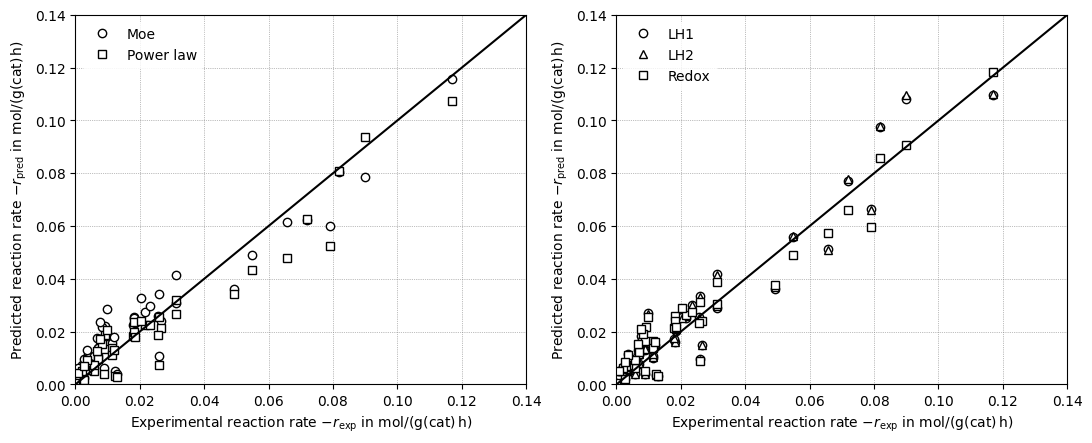

In [29]:
from phdtools.plots.wgs import plot_parity_rate_of_conversion_mendes_2010

fname = (
    DataID(DataType.FIGURE, Chapter.UNUSED, 13).get_path(fail_exists=False)
    / f"{FILE_DATE}_reaction_rates.csv"
)
fig = plot_parity_rate_of_conversion_mendes_2010(fname, method="forward")

## Choi and Stenger, 2003
[back](#Table-of-contents)

The material balance is given by
$$
\dd F_\ce{CO} = R_\ce{CO} \mathrm{d} W
% \label{eq:material-balance}
$$

Defining $\ce{CO}$ conversion as
$$
X_\ce{CO} = \frac{F_{\ce{CO},0} - F_{\ce{CO}}}{F_{\ce{CO},0}} 
$$

$$
\dd X_\ce{CO} = - \frac{\dd  F_{\ce{CO}}}{F_{\ce{CO},0}} 
$$

Thus
$$
\dd X_\ce{CO} = - R_\ce{CO} \, \mathrm{d} (W/F_{\ce{CO},0})
% \label{eq:material-balance}
$$

Or
$$
\frac{\dd X_\ce{CO}}{\mathrm{d} (W/F_{\ce{CO},0})} = r 
% \label{eq:material-balance}
$$

### Experimental data

In [30]:
!ls {DATA_DIR / "choi-stenger-2003"}

250723_figure_2_experimental_choi_stenger_2003.csv
250723_figure_3_experimental_choi_stenger_2003.csv


In [31]:
fname = (
    DATA_DIR
    / "choi-stenger-2003"
    / "250723_figure_2_experimental_choi_stenger_2003.csv"
)

data_figure_2 = pd.read_csv(fname, comment="#", names=["H2O/CO", "XCO", "T(C)"])
data_figure_2.head()

,H2O/CO,XCO,T(C)
0,0.590231,0.089669,120
1,0.461330,0.163743,155
2,0.223881,0.122807,175
3,0.685210,0.374269,190
4,0.654681,0.559454,220


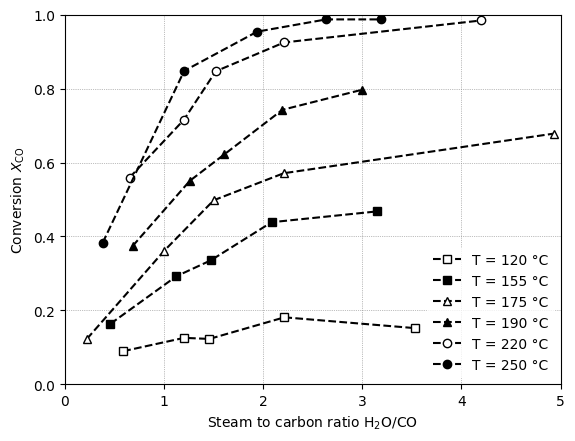

In [32]:
from phdtools.plots.wgs import plot_conversion_vs_steam_to_carbon_experiment

fig = plot_conversion_vs_steam_to_carbon_experiment()

In [33]:
fname = (
    DATA_DIR
    / "choi-stenger-2003"
    / "250723_figure_3_experimental_choi_stenger_2003.csv"
)

data_figure_3 = pd.read_csv(fname, comment="#", names=["GHSV(1/h)", "XCO", "T(C)"])
data_figure_3.head()

,GHSV(1/h),XCO,T(C)
0,18280.802292,0.151129,155
1,18295.128940,0.291462,190
2,18323.782235,0.522080,220
3,12177.650430,0.180569,155
4,12177.650430,0.365064,190


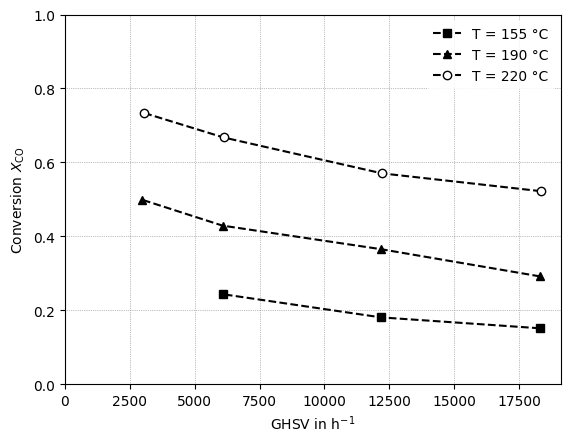

In [34]:
from phdtools.plots.wgs import plot_conversion_vs_space_velocity

fig = plot_conversion_vs_space_velocity()

#### Convesion of space velocity

[Choi and Stenger (2003)](#References) report carbon monoxide conversion as a function of gas hourly space velocity ($\mathrm{GHSV}$) at **reaction temperature** [(Choi and Stenger, 2003, p. 434)](#References). 
According to [Levenspiel (1999)](#References), *space-time* is $\tau$ may be defined by 
$$
\tau = \frac{C_{\mathrm{CO},0}\,V}{F_{\mathrm{CO},0}} = \frac{V_\mathrm{ref}}{\dot{V}} = \frac{3600\,\mathrm{h}}{\mathrm{GHSV}}
$$
where:
* $F_{\ce{CO},0}$ denotes the molar feed rate of carbon monoxide
* $C_{\mathrm{CO},0}$ is the concentration of carbon monoxide in the feed
* $\dot{V}$ is the volumetric flow rate of the feed gas in $\mathrm{m^3/h}$, and
* $V$ is a reference volume. This could be either the (geometric) reactor volume $V_r$, the volume of solids $V_s$ or fluid volume $V = V_r - V_s$
  
According to the experimental description, the reactor is a tubular steel reactor with:
* Inner diameter $D = 1/2\,\mathrm{in.} = 12.7 \,\mathrm{mm}$, and
* Length $L = 12\,\mathrm{in.} \approx 304.79 \,\mathrm{mm}$

Thus, the reactor volume is:
$$
V_r = \pi/4 \, D^2 \, L \approx 38611.12 \, \mathrm{mm^3} = 3.861 \times 10^{-5} \, \mathrm{m^3} 
$$

The catalyst loading reported is 
$$
W = 1 \mathrm{g}
$$
The catalyst bulk density can be estimated to be $ \approx 1200 \frac{\mathrm{kg}}{\mathrm{m^3} }$, giving
$$
V_s = \frac{1\times 10^{-3} \, \mathrm{kg}}{1200\,\mathrm{kg}/\mathrm{m^3}} \approx 8.33\times 10^{-7}\,\mathrm{m^3}
$$
Thus the volume of fluid is, 
$$
V = 3.78 \times 10^{-5} \, \mathrm{m^3} 
$$
assuming no diluting particles were added.

Since neither catalyst *density* nor *bed porosity* is reported, we assume that $\tau$ (or $\mathrm{GHSV}$) is defined based on the total geometric volume of the reactor $V_r$ rather than the solid catalyst volume $V_s$ or the fluid volume $V$.

For validation we want to relate $\mathrm{GHSV}$ with $W/F_{\ce{CO},0}$ which appears naturally in the performance equations. 
Analogous to space-time, we define *weight-time* by (see [Levenspiel, 1999](#References)):
$$
\tau^\prime = \frac{C_{\mathrm{CO},0}\,W}{F_{\mathrm{CO},0}} = \frac{W}{V_\mathrm{ref}} \tau
$$

**Variants:**
Depending on the definition of $V_\mathrm{ref}$ there are three possibilities to derive weight-time
$$
\frac{W}{V_r} = \frac{1\times 10^{-3} \, \mathrm{kg}}{3.861 \times 10^{-5} \, \mathrm{m^3} } \approx 25.8 \frac{\mathrm{kg}}{\mathrm{m^3} }
$$

$$
\frac{W}{V_s} = 1200 \frac{\mathrm{kg}}{\mathrm{m^3} }
$$

Assuming ideal gas behaviour, the concentration of $\ce{CO}$ at the inlet is:
$$
C_{\ce{CO},0} = \frac{n_{\ce{CO},0}}{V} = \frac{p_{\ce{CO},0}}{R T} = \frac{p}{R T} x_{\ce{CO},0}
$$
where:
* $p_{\ce{CO},0}$ is the partial pressure of $\ce{CO}$ at the inlet,
* $x_{\ce{CO},0}$ is the mole fraction of $\ce{CO}$ at the inlet,
* $p$ is the total (static) pressure
* $R$ is the gas constant,
* $T$ is the temperature.

**Variants:**
Depending on the reference state of $p,T$ (standard temperature and pressure, or reaction temperature and pressure) and mole fraction (dry gas or including steam) there are four ways to obtain $C_{\ce{CO},0}$


**In total we have to check 12 ways to relate $\mathrm{GHSV}$ with $W/F_{\ce{CO},0}$. From fig. 5 we can derive that $F_{\ce{CO},0}$ must be within $0$ to $0.08\,\mathrm{mol/h}$**.  

In [35]:
from phdtools.models.choi_stenger_2003 import (
    CATALYST_VOLUME_CUBIC_METER,
    CATALYST_MASS_KILOGRAMM,
    REACTOR_VOLUME_CUBIC_METER,
)

# CATALYST_VOLUME_CUBIC_METER = CATALYST_MASS_KILOGRAMM / 1200
# CATALYST_VOLUME_CUBIC_METER = CATALYST_MASS_KILOGRAMM / 500
# CATALYST_MASS_KILOGRAMM = REACTOR_VOLUME_CUBIC_METER * CATALYST_MASS_KILOGRAMM
# CATALYST_VOLUME_CUBIC_METER = REACTOR_VOLUME_CUBIC_METER

In [36]:
GHSV = 6100

data_figure_2["tau' 1"] = (
    3600 / GHSV * CATALYST_MASS_KILOGRAMM / REACTOR_VOLUME_CUBIC_METER
)
data_figure_2["tau' 2"] = (
    3600 / GHSV * CATALYST_MASS_KILOGRAMM / CATALYST_VOLUME_CUBIC_METER
)

data_figure_2.head()

,H2O/CO,XCO,T(C),tau' 1,tau' 2
0,0.590231,0.089669,120,15.284822,708.196721
1,0.461330,0.163743,155,15.284822,708.196721
2,0.223881,0.122807,175,15.284822,708.196721
3,0.685210,0.374269,190,15.284822,708.196721
4,0.654681,0.559454,220,15.284822,708.196721


In [37]:
pressureBar = 1.01325
hydrogenToCarbonMonoxideRatio = 2

data_figure_2["T(K)"] = data_figure_2["T(C)"] + 273.15

data_figure_2["c_CO,0(mol/m3) 1"] = (
    pressureBar
    * 1e5
    * 1
    / (1 + hydrogenToCarbonMonoxideRatio + data_figure_2["H2O/CO"])
    / (GAS_CONST_SI * data_figure_2["T(K)"])
)
data_figure_2["c_CO,0(mol/m3) 2"] = (
    pressureBar
    * 1e5
    * 1
    / (1 + hydrogenToCarbonMonoxideRatio + data_figure_2["H2O/CO"])
    / (GAS_CONST_SI * 273.15)
)
data_figure_2["c_CO,0(mol/m3) 3"] = (
    pressureBar
    * 1e5
    * 1
    / (1 + hydrogenToCarbonMonoxideRatio)
    / (GAS_CONST_SI * data_figure_2["T(K)"])
)
data_figure_2["c_CO,0(mol/m3) 4"] = (
    pressureBar
    * 1e5
    * 1
    / (1 + hydrogenToCarbonMonoxideRatio)
    / (GAS_CONST_SI * 273.15)
)

data_figure_2.head()

,H2O/CO,XCO,T(C),tau' 1,tau' 2,T(K),"c_CO,0(mol/m3) 1","c_CO,0(mol/m3) 2","c_CO,0(mol/m3) 3","c_CO,0(mol/m3) 4"
0,0.590231,0.089669,120,15.284822,708.196721,393.15,8.633796,12.426787,10.332440,14.871678
1,0.461330,0.163743,155,15.284822,708.196721,428.15,8.223250,12.889565,9.487794,14.871678
2,0.223881,0.122807,175,15.284822,708.196721,448.15,8.434903,13.838922,9.064373,14.871678
3,0.685210,0.374269,190,15.284822,708.196721,463.15,7.140004,12.106509,8.770806,14.871678
4,0.654681,0.559454,220,15.284822,708.196721,493.15,6.761669,12.207640,8.237248,14.871678


<Axes: >

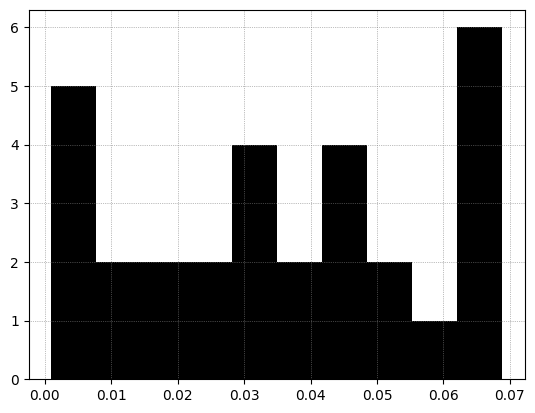

In [38]:
data_figure_2["W/F_CO,0(kg*s/mol)"] = (
    data_figure_2["tau' 2"] / data_figure_2["c_CO,0(mol/m3) 4"]
)

data_figure_2["F_CO,0(mol/s)"] = (
    CATALYST_MASS_KILOGRAMM / data_figure_2["W/F_CO,0(kg*s/mol)"]
)
data_figure_2["F_CO(mol/s)"] = data_figure_2["F_CO,0(mol/s)"] * (
    1 - data_figure_2["XCO"]
)

(data_figure_2["F_CO(mol/s)"] * 3600).hist()

**The best fit is achieved with $V = V_s$ and $\mathrm{GHSV}$ computed at standard pressure $p = 1\,\mathrm{atm}$ and temperature $T = 273.15\,\mathrm{K}$** and using the mole fraction of dry gas. 
This is problematic because it is inconsistent with the description of experimental setup. 

In [39]:
hydrogenToCarbonMonoxideRatio = 2
steamToCarbonMonoxideRatio = 0  # dry

data_figure_3["T(K)"] = data_figure_3["T(C)"] + 273.15

data_figure_3["c_CO,0(mol/m3)"] = (
    pressureBar
    * 1e5
    * 1
    / (1 + hydrogenToCarbonMonoxideRatio + steamToCarbonMonoxideRatio)
    / (GAS_CONST_SI * 273.15)
)
data_figure_3["F_CO,0(mol/s)"] = (
    data_figure_3["c_CO,0(mol/m3)"]
    * data_figure_3["GHSV(1/h)"]
    / 3600
    * CATALYST_VOLUME_CUBIC_METER
)
data_figure_3["F_CO(mol/s)"] = data_figure_3["F_CO,0(mol/s)"] * (
    1 - data_figure_3["XCO"]
)
data_figure_3["W/F_CO,0(kg*s/mol)"] = (
    CATALYST_MASS_KILOGRAMM / data_figure_3["F_CO,0(mol/s)"]
)

data_figure_3.head()

,GHSV(1/h),XCO,T(C),T(K),"c_CO,0(mol/m3)","F_CO,0(mol/s)",F_CO(mol/s),"W/F_CO,0(kg*s/mol)"
0,18280.802292,0.151129,155,428.15,14.871678,0.000063,0.000053,15.890169
1,18295.128940,0.291462,190,463.15,14.871678,0.000063,0.000045,15.877726
2,18323.782235,0.522080,220,493.15,14.871678,0.000063,0.000030,15.852898
3,12177.650430,0.180569,155,428.15,14.871678,0.000042,0.000034,23.853948
4,12177.650430,0.365064,190,463.15,14.871678,0.000042,0.000027,23.853948


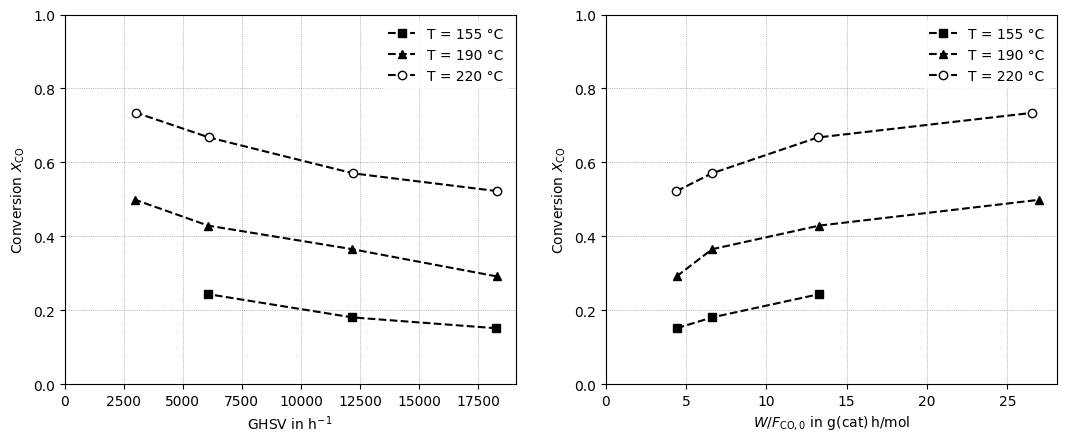

In [40]:
import matplotlib.pyplot as plt
from phdtools.plots.wgs import plot_conversion_vs_space_time_converted

fig, axs = plt.subplots(1, 2, figsize=(2 * 6.4, 4.8))

_ = plot_conversion_vs_space_velocity(ax=axs[0])
_ = plot_conversion_vs_space_time_converted(data=data_figure_3, ax=axs[1])

### Kinetics

[Choi and Stenger, 2003](#References) tested five different rate expressions modelling the WGS reaction \eqref{eq:WGS} over a $\ce{Cu}$/$\ce{ZnO}$/$\ce{Al2O3}$ catalyst between 120 and 250 °C. 
The authors found the emprical rate expression 
$$
\ReactionRate{} = k \, \PartialPressure{\ce{CO}}\,\PartialPressure{\ce{H2O}} (1 - \beta) \quad \text{where} \quad \beta = \frac{\PartialPressure{\ce{H2}}\,\PartialPressure{\ce{CO2}}}{\PartialPressure{\ce{CO}}\,\PartialPressure{\ce{H2O}}\,K_2}
$$
to fit their expirental data sufficiently well, yielding an $R^2$-value of 0.986.

$$
k = k_0 \exp{\left(\frac{E}{R T}\right)} \quad \text{with} \quad k_0 = 2.96\times 10^5 \,\mathrm{mol/(g(cat)\,h\,atm^2)}, E = 47.4\:\mathrm{kJ/mol}
$$

In [41]:
from phdtools.models.choi_stenger_2003 import reactionRateModel

steamToCarbonMonoxideRatio = 1.2

moleFractionIn = 0 * np.ones(len(Compound))

moleFractionIn[Compound["C1H4(g)"].value] = 0
moleFractionIn[Compound["C1O1(g)"].value] = 1 / (
    1 + hydrogenToCarbonMonoxideRatio + steamToCarbonMonoxideRatio
)
moleFractionIn[Compound["C1O2(g)"].value] = 0
moleFractionIn[Compound["H2(ref)"].value] = hydrogenToCarbonMonoxideRatio / (
    1 + hydrogenToCarbonMonoxideRatio + steamToCarbonMonoxideRatio
)
moleFractionIn[Compound["H2O1(g)"].value] = steamToCarbonMonoxideRatio / (
    1 + hydrogenToCarbonMonoxideRatio + steamToCarbonMonoxideRatio
)

partialPressureBar = pressureBar * moleFractionIn
temperatureKelvin = 900

r = reactionRateModel(partialPressureBar, temperatureKelvin, model="vantHoff")[0]

print(
    f"r_CO({pressureBar} bar, {temperatureKelvin} K) = {-r:.2f} mol/(kg(cat) * s) = {-r*3.6:.2f} mol/(g(cat) * h)"
)

r_CO(1.01325 bar, 900 K) = -9.92 mol/(kg(cat) * s) = -35.73 mol/(g(cat) * h)


### Integration

In [42]:
from scipy.integrate import solve_ivp
from phdtools.models.choi_stenger_2003 import (
    initialValueProblem,
    initialValueProblemConversion,
)

### Validation

$$
\text{Space-time}: \quad \tau = \frac{C_{\mathrm{CO},0}\,V}{F_{\mathrm{CO},0}}
$$

$$
\tau^\prime = \frac{C_{\mathrm{CO},0}\,W}{F_{\mathrm{CO},0}}
$$$$
\frac{\dd (W/F_{\ce{CO},0})}{\dd X_\ce{CO}} = 1/r 
% \label{eq:material-balance}
$$

### Parity plot of exiting CO flowrate

In [43]:
import numpy as np
import pandas as pd
from phdtools import DATA_DIR

fname = (
    DATA_DIR
    / "choi-stenger-2003"
    / "250723_figure_2_experimental_choi_stenger_2003.csv"
)
data_figure_2 = pd.read_csv(fname, comment="#", names=["H2O/CO", "XCO", "T(C)"])

data_figure_2["tau' 2"] = (
    3600 / GHSV * CATALYST_MASS_KILOGRAMM / CATALYST_VOLUME_CUBIC_METER
)
data_figure_2["c_CO,0(mol/m3) 4"] = (
    pressureBar
    * 1e5
    * 1
    / (1 + hydrogenToCarbonMonoxideRatio)
    / (GAS_CONST_SI * 273.15)
)
data_figure_2["W/F_CO,0(kg*s/mol)"] = (
    data_figure_2["tau' 2"] / data_figure_2["c_CO,0(mol/m3) 4"]
)

data_figure_2["F_CO,0(mol/s)"] = (
    CATALYST_MASS_KILOGRAMM / data_figure_2["W/F_CO,0(kg*s/mol)"]
)
data_figure_2["F_CO(mol/s)"] = data_figure_2["F_CO,0(mol/s)"] * (
    1 - data_figure_2["XCO"]
)

In [44]:
data_figure_2.head()

,H2O/CO,XCO,T(C),tau' 2,"c_CO,0(mol/m3) 4","W/F_CO,0(kg*s/mol)","F_CO,0(mol/s)",F_CO(mol/s)
0,0.590231,0.089669,120,708.196721,14.871678,47.620499,0.000021,0.000019
1,0.461330,0.163743,155,708.196721,14.871678,47.620499,0.000021,0.000018
2,0.223881,0.122807,175,708.196721,14.871678,47.620499,0.000021,0.000018
3,0.685210,0.374269,190,708.196721,14.871678,47.620499,0.000021,0.000013
4,0.654681,0.559454,220,708.196721,14.871678,47.620499,0.000021,0.000009


In [45]:
from scipy.integrate import solve_ivp
from phdtools.models.choi_stenger_2003 import (
    initialValueProblem,
    initialValueProblemConversion,
)

hydrogenToCarbonMonoxideRatio = 2
pressureBar = 1.01325

flowRateCOIn = np.zeros((len(data_figure_2)))
flowRateCOOut = np.zeros((len(data_figure_2)))
moleFractionIn = 0 * np.ones((len(Compound)))
# moleFractionInDry = 0 * np.ones((len(Compound)))

for idx in data_figure_2.index:
    conversion = np.linspace(0, data_figure_2["XCO"][idx])
    steamToCarbonMonoxideRatio = data_figure_2["H2O/CO"][idx]
    temperatureKelvin = data_figure_2["T(C)"][idx] + 273.15

    moleFractionIn[Compound["C1H4(g)"].value] = 0
    moleFractionIn[Compound["C1O1(g)"].value] = 1 / (
        1 + hydrogenToCarbonMonoxideRatio + steamToCarbonMonoxideRatio
    )
    moleFractionIn[Compound["C1O2(g)"].value] = 0
    moleFractionIn[Compound["H2(ref)"].value] = hydrogenToCarbonMonoxideRatio / (
        1 + hydrogenToCarbonMonoxideRatio + steamToCarbonMonoxideRatio
    )
    moleFractionIn[Compound["H2O1(g)"].value] = steamToCarbonMonoxideRatio / (
        1 + hydrogenToCarbonMonoxideRatio + steamToCarbonMonoxideRatio
    )

    sol = solve_ivp(
        fun=initialValueProblemConversion,
        t_span=[0, conversion.max()],
        y0=[0],
        method="RK45",
        t_eval=conversion,
        dense_output=False,
        events=None,
        vectorized=True,
        args=(moleFractionIn, temperatureKelvin, pressureBar, "choi11"),
    )
    flowRateCOIn[idx] = CATALYST_MASS_KILOGRAMM / sol.y[0][-1]
    flowRateCOOut[idx] = flowRateCOIn[idx] * (1 - sol.t[-1])

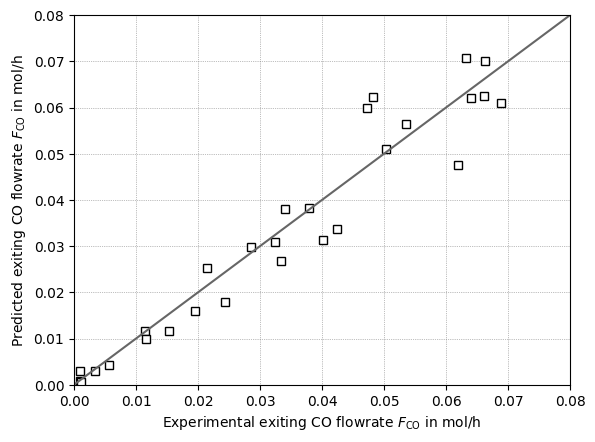

In [46]:
import matplotlib.pyplot as plt


def plot_pairity_of_flow_rate_choi_stenger_fig_5(fname_experimental, fname_model):
    fig = plt.figure()
    ax = fig.gca()

    frame = pd.read_csv(
        fname_experimental, comment="#", names=["H2O/CO", "XCO", "T(C)"]
    )

    frame["tau' 2"] = (
        3600 / GHSV * CATALYST_MASS_KILOGRAMM / CATALYST_VOLUME_CUBIC_METER
    )
    frame["c_CO,0(mol/m3) 4"] = (
        pressureBar
        * 1e5
        * 1
        / (1 + hydrogenToCarbonMonoxideRatio)
        / (GAS_CONST_SI * 273.15)
    )
    frame["W/F_CO,0(kg*s/mol)"] = frame["tau' 2"] / frame["c_CO,0(mol/m3) 4"]

    frame["F_CO,0(mol/s)"] = CATALYST_MASS_KILOGRAMM / frame["W/F_CO,0(kg*s/mol)"]
    frame["F_CO(mol/s)"] = frame["F_CO,0(mol/s)"] * (1 - frame["XCO"])

    ax.plot(
        frame["F_CO(mol/s)"] * 3600,
        flowRateCOOut * 3600,
        marker="s",
        mec="black",
        mfc="white",
        linestyle="none",
    )
    # ax.plot(data_figure_2["H2O/CO"],data_figure_2["XCO"],".")
    # ax.plot(data_figure_2["H2O/CO"],conversion,".")

    ax.plot([0, 0.08], [0, 0.08])

    ax.set_xlim(0, 0.08)
    ax.set_ylim(0, 0.08)

    ax.set_xlabel(
        r"Experimental exiting CO flowrate $F_\mathrm{CO}$ in $\mathrm{mol/h}$"
    )
    ax.set_ylabel(r"Predicted exiting CO flowrate $F_\mathrm{CO}$ in $\mathrm{mol/h}$")

    ax.grid(True)


plot_pairity_of_flow_rate_choi_stenger_fig_5(
    fname_experimental=DATA_DIR
    / "choi-stenger-2003"
    / "250723_figure_2_experimental_choi_stenger_2003.csv",
    fname_model=None,
)

### Space-time vs. conversion

$$
\frac{\dd (W/F_{\ce{CO},0})}{\dd X_\ce{CO}} = 1/r 
% \label{eq:material-balance}
$$

In [47]:
hydrogenToCarbonMonoxideRatio = 2
steamToCarbonMonoxideRatio = 1.3

moleFractionIn = 0 * np.ones(len(Compound))

moleFractionIn[Compound["C1H4(g)"].value] = 0
moleFractionIn[Compound["C1O1(g)"].value] = 1 / (
    1 + hydrogenToCarbonMonoxideRatio + steamToCarbonMonoxideRatio
)
moleFractionIn[Compound["C1O2(g)"].value] = 0
moleFractionIn[Compound["H2(ref)"].value] = hydrogenToCarbonMonoxideRatio / (
    1 + hydrogenToCarbonMonoxideRatio + steamToCarbonMonoxideRatio
)
moleFractionIn[Compound["H2O1(g)"].value] = steamToCarbonMonoxideRatio / (
    1 + hydrogenToCarbonMonoxideRatio + steamToCarbonMonoxideRatio
)

pressureBar = 1.01325
temperatureRange = np.array([155, 190, 220]) + 273.15

In [48]:
conversion = np.zeros((len(temperatureRange), 100))
spaceTime = np.zeros((len(temperatureRange), 100))
spaceVelocity = np.zeros((len(temperatureRange), 100))
spaceTime[:] = np.nan

for num, temperatureKelvin in enumerate(temperatureRange):
    eqConversion = equilibriumConversionWGS(
        moleFractionIn, temperatureKelvin, model="vantHoff"
    )
    conversion[num] = np.linspace(0, eqConversion, 100)
    sol = solve_ivp(
        fun=initialValueProblemConversion,
        t_span=[conversion.min(), conversion.max()],
        y0=[0],
        method="RK45",
        t_eval=conversion[num],
        dense_output=False,
        events=None,
        vectorized=True,
        args=(moleFractionIn, temperatureKelvin, pressureBar),
    )

    spaceTime[num] = sol.y[0]
    concentrationIn = moleFractionIn * pressureBar * 1e5 / (273.15 * GAS_CONST_SI)

    spaceVelocity[num] = (CATALYST_MASS_KILOGRAMM / CATALYST_VOLUME_CUBIC_METER) / (
        spaceTime[num] * concentrationIn[Compound["C1O1(g)"].value]
    )

/var/folders/zx/th579dkn46lg9lcpb6980qb40000gn/T/ipykernel_51919/2006993917.py:26: RuntimeWarning: divide by zero encountered in divide
  spaceVelocity[num] = (CATALYST_MASS_KILOGRAMM / CATALYST_VOLUME_CUBIC_METER) / (


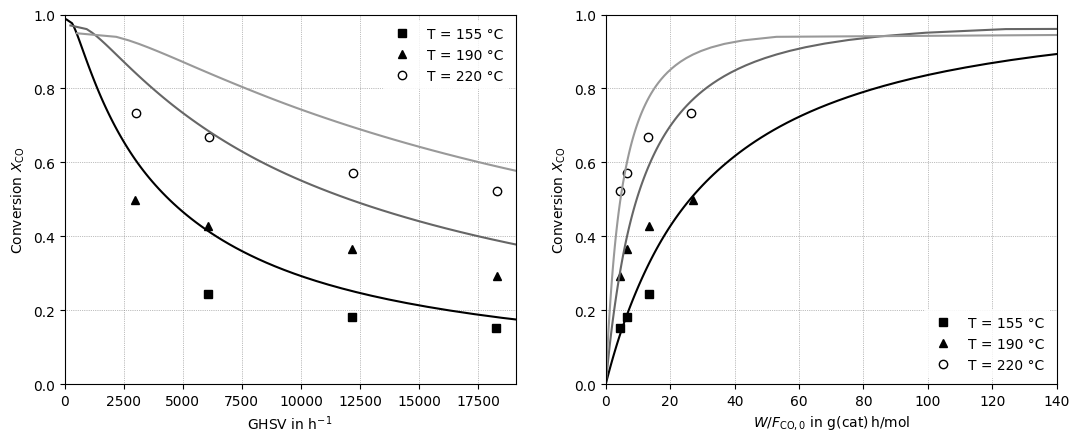

In [49]:
fig, axs = plt.subplots(1, 2, figsize=(2 * 6.4, 4.8))

_ = plot_conversion_vs_space_velocity(ax=axs[0], ls="none")
for num, temperatureKelvin in enumerate(temperatureRange):
    axs[0].plot(
        spaceVelocity[num] * 3600,
        conversion[num],
        label=f"T = {temperatureKelvin-273.15} °C",
    )

_ = plot_conversion_vs_space_time_converted(data=data_figure_3, ax=axs[1], ls="none")
for num, temperatureKelvin in enumerate(temperatureRange):
    axs[1].plot(
        spaceTime[num] / 3.6,
        conversion[num],
        label=f"T = {temperatureKelvin-273.15} °C",
    )

axs[1].set_xlim(0, 140)

for ax in axs:
    ax.grid(True)

## References
[back](#Table-of-contents)

1. Mendes, D. et al. (2010) ‘Determination of the Low-Temperature Water−Gas Shift Reaction Kinetics Using a Cu-Based Catalyst’, Industrial & Engineering Chemistry Research, 49(22), pp. 11269–11279. Available at: https://doi.org/10.1021/ie101137b.
2. Choi, Y. and Stenger, H.G. (2003) ‘Water gas shift reaction kinetics and reactor modeling for fuel cell grade hydrogen’, Journal of Power Sources, 124(2), pp. 432–439. Available at: https://doi.org/10.1016/S0378-7753(03)00614-1.